# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Ahmad Zaky Alfuady]
- **Email:** [spacejunk2077@gmail.com]
- **ID Dicoding:** [APC355D6Y0100]

## Import Semua Packages/Library yang Digunakan

In [1]:
# Library dasar
import os
import shutil
import zipfile
import random
from pathlib import Path

# Library pengolahan data
import numpy as np
import pandas as pd

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm.notebook import tqdm as tq

# Library pemrosesan gambar
import cv2
from PIL import Image

# Library machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

# Download dataset Kaggle
import kagglehub

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

# Cek versi TensorFlow
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Data Preparation

### Data Loading

In [2]:
# Download dataset Intel Image Classification dari Kaggle
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path dataset:", path)

# Melihat isi dataset
dataset_path = Path(path)
for item in dataset_path.iterdir():
    print(item)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path dataset: /kaggle/input/intel-image-classification
/kaggle/input/intel-image-classification/seg_train
/kaggle/input/intel-image-classification/seg_pred
/kaggle/input/intel-image-classification/seg_test


In [3]:
# Definisikan direktori dataset
train_dir = dataset_path / "seg_train" / "seg_train"
test_dir = dataset_path / "seg_test" / "seg_test"

print("Train Directory :", train_dir)
print("Test Directory  :", test_dir)

# Menampilkan nama kelas
classes = os.listdir(train_dir)

print("Daftar Kelas:")
for cls in classes:
    print("-", cls)

Train Directory : /kaggle/input/intel-image-classification/seg_train/seg_train
Test Directory  : /kaggle/input/intel-image-classification/seg_test/seg_test
Daftar Kelas:
- mountain
- street
- buildings
- sea
- forest
- glacier


In [4]:
# Melihat jumlah gambar pada setiap kelas
train_counts = {}

for category in os.listdir(train_dir):
    category_path = os.path.join(train_dir, category)
    train_counts[category] = len(os.listdir(category_path))

# Menampilkan jumlah gambar
train_counts

# Membuat DataFrame distribusi dataset
distribution_df = pd.DataFrame({
    "Class": train_counts.keys(),
    "Total Images": train_counts.values()
})

distribution_df

,Class,Total Images
0,mountain,2512
1,street,2382
2,buildings,2191
3,sea,2274
4,forest,2271
5,glacier,2404


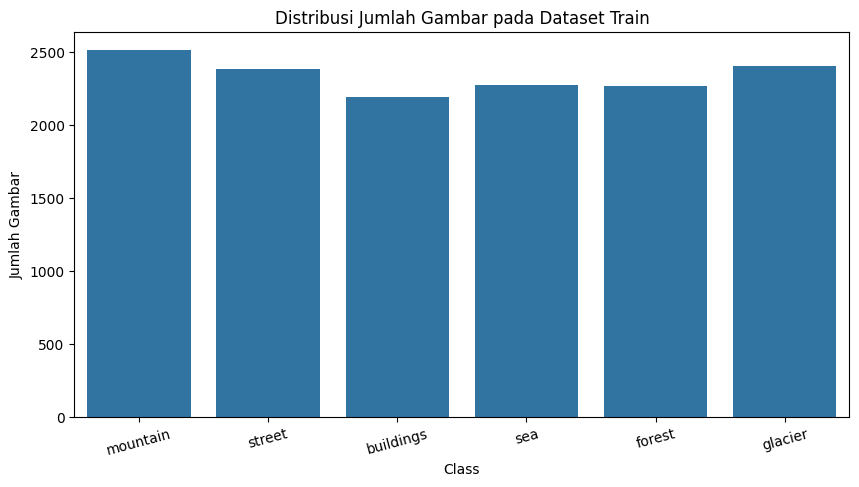

In [5]:
# Visualisasi distribusi dataset
plt.figure(figsize=(10,5))

sns.barplot(
    x="Class",
    y="Total Images",
    data=distribution_df
)

plt.title("Distribusi Jumlah Gambar pada Dataset Train")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=15)

plt.show()

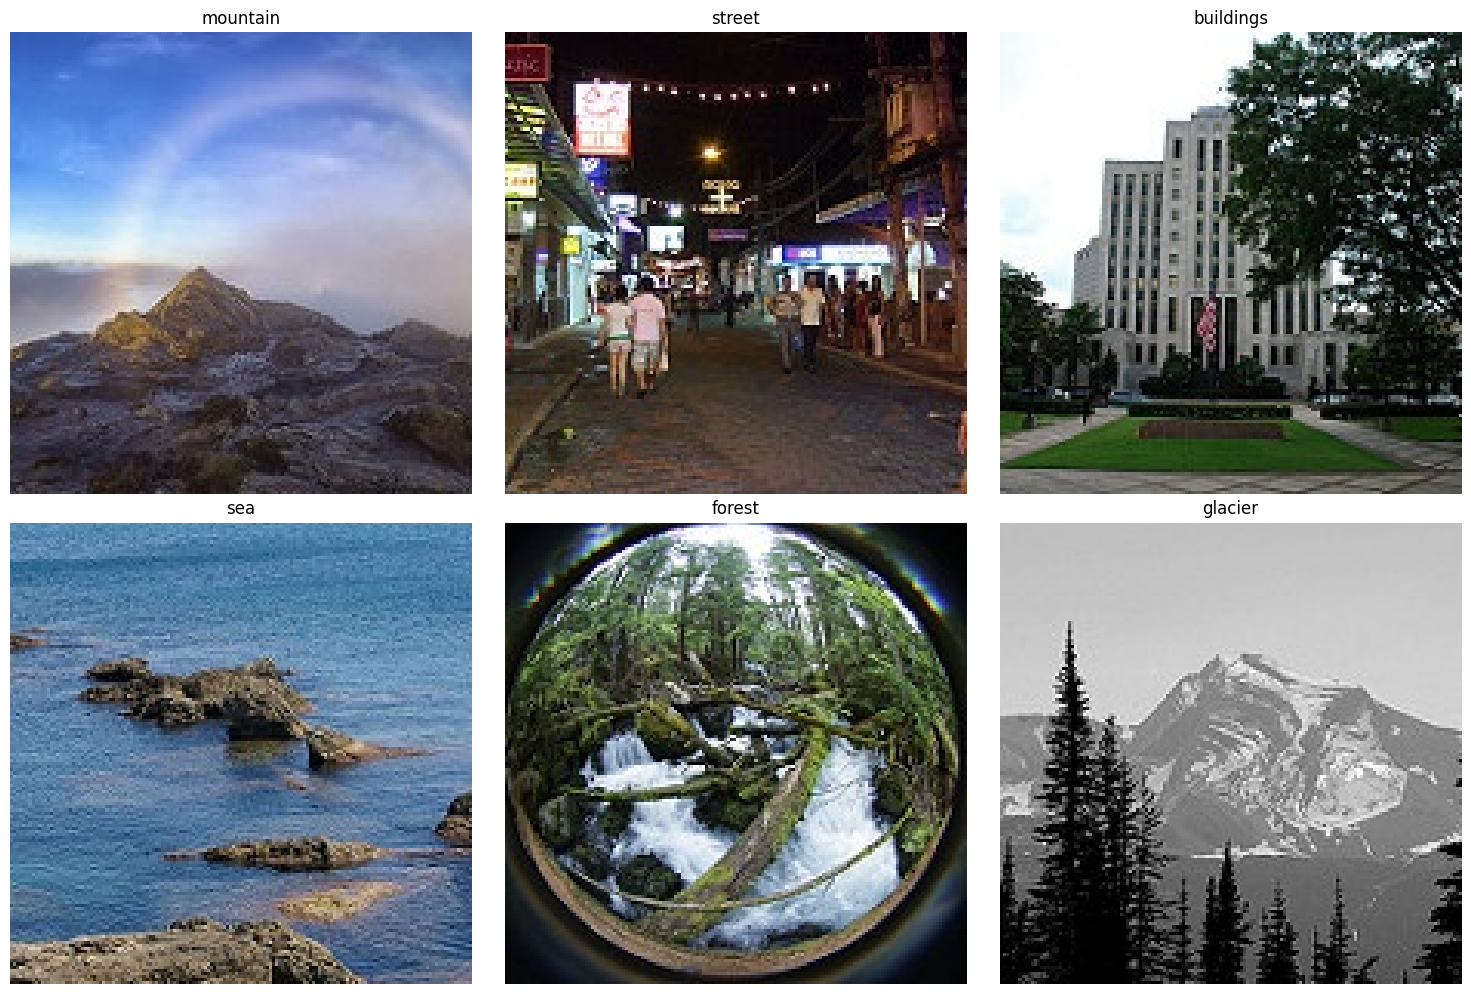

In [6]:
# Menampilkan contoh gambar dari setiap kelas
classes = os.listdir(train_dir)

plt.figure(figsize=(15,10))

for i, category in enumerate(classes):
    category_path = os.path.join(train_dir, category)
    image_name = random.choice(os.listdir(category_path))
    image_path = os.path.join(category_path, image_name)
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Mengecek variasi resolusi gambar
image_sizes = []

for category in classes:
    category_path = os.path.join(train_dir, category)
    sample_images = os.listdir(category_path)[:100]
    for image_name in sample_images:
        image_path = os.path.join(category_path, image_name)
        img = Image.open(image_path)
        image_sizes.append(img.size)

# Melihat beberapa resolusi unik
unique_sizes = list(set(image_sizes))

print("Jumlah resolusi unik:", len(unique_sizes))
print("Contoh resolusi gambar:")
print(unique_sizes[:10])

Jumlah resolusi unik: 5
Contoh resolusi gambar:
[(150, 149), (150, 113), (150, 135), (150, 141), (150, 150)]


### Data Preprocessing

#### Split Dataset

In [8]:
# Folder gabungan dataset
combined_dir = "combined_dataset"

os.makedirs(combined_dir, exist_ok=True)

# Sumber dataset
sources = [
    train_dir,
    test_dir
]

# Menggabungkan dataset train dan test bawaan
for source in sources:
    for category in os.listdir(source):
        source_category = os.path.join(source, category)
        target_category = os.path.join(combined_dir, category)
        os.makedirs(target_category, exist_ok=True)
        for file in os.listdir(source_category):
            src_file = os.path.join(source_category, file)
            dst_file = os.path.join(target_category, file)
            shutil.copy2(src_file, dst_file)

print("Dataset berhasil digabung")

Dataset berhasil digabung


In [9]:
# Membuat DataFrame Dataset

filepaths = []
labels = []

# Mengambil seluruh gambar dari dataset gabungan
for category in os.listdir(combined_dir):
    category_path = os.path.join(combined_dir, category)
    for file in os.listdir(category_path):
        filepath = os.path.join(category_path, file)
        filepaths.append(filepath)
        labels.append(category)

# Membuat DataFrame
df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

# Menampilkan 5 data pertama
df.head()

,filepath,label
0,combined_dataset/mountain/20876.jpg,mountain
1,combined_dataset/mountain/8902.jpg,mountain
2,combined_dataset/mountain/6760.jpg,mountain
3,combined_dataset/mountain/6036.jpg,mountain
4,combined_dataset/mountain/5306.jpg,mountain


In [10]:
# Split train dan temporary
train_data, temp_data = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],
    random_state=42
)

# Split validation dan test
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    stratify=temp_data['label'],
    random_state=42
)

print("Jumlah Data Training   :", len(train_data))
print("Jumlah Data Validation :", len(val_data))
print("Jumlah Data Testing    :", len(test_data))

Jumlah Data Training   : 11923
Jumlah Data Validation : 2555
Jumlah Data Testing    : 2556


In [11]:
# Distribusi Dataset

print("Training Set")
print(train_data['label'].value_counts())

print("\nValidation Set")
print(val_data['label'].value_counts())

print("\nTesting Set")
print(test_data['label'].value_counts())

Training Set
label
mountain     2126
glacier      2070
street       2018
sea          1949
forest       1921
buildings    1839
Name: count, dtype: int64

Validation Set
label
mountain     455
glacier      443
street       432
sea          418
forest       412
buildings    395
Name: count, dtype: int64

Testing Set
label
mountain     456
glacier      444
street       433
sea          417
forest       412
buildings    394
Name: count, dtype: int64


In [12]:
# Image Data Generator

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,

    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
# Data Generator

# Ukuran gambar
IMG_SIZE = (150, 150)

# Batch size
BATCH_SIZE = 32

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='filepath',
    y_col='label',

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,

    class_mode='categorical',
    shuffle=True
)

# Validation generator
validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='filepath',
    y_col='label',

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,

    class_mode='categorical',
    shuffle=False
)

# Testing generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_data,
    x_col='filepath',
    y_col='label',

    target_size=IMG_SIZE,
    batch_size=1,

    class_mode='categorical',
    shuffle=False
)

Found 11923 validated image filenames belonging to 6 classes.
Found 2555 validated image filenames belonging to 6 classes.
Found 2556 validated image filenames belonging to 6 classes.


In [14]:
# Informasi Label

print("Class Indices:")
print(train_generator.class_indices)

Class Indices:
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## Modelling

In [15]:
# Membuat model Sequential CNN
model = Sequential([

    # Layer 1
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(150,150,3)
    ),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer 2
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer 3
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Layer 4
    Conv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    ),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Output Layer
    Dense(6, activation='softmax')
])

In [16]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Ringkasan model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,140,550 (42.50 MB)

 Trainable params: 11,139,590 (42.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
# Callback

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

# Save best model
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [19]:
# Training Model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=100,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 99s 236ms/step - accuracy: 0.4594 - loss: 2.9164 - val_accuracy: 0.4059 - val_loss: 1.5700 - learning_rate: 0.0010
Epoch 2/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 124s 206ms/step - accuracy: 0.5822 - loss: 1.1484 - val_accuracy: 0.6630 - val_loss: 0.9413 - learning_rate: 0.0010
Epoch 3/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - accuracy: 0.6607 - loss: 0.9373 - val_accuracy: 0.6125 - val_loss: 0.9501 - learning_rate: 0.0010
Epoch 4/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 76s 203ms/step - accuracy: 0.7006 - loss: 0.8449 - val_accuracy: 0.5409 - val_loss: 1.1658 - learning_rate: 0.0010
Epoch 5/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 76s 203ms/step - accuracy: 0.7244 - loss: 0.7808 - val_accuracy: 0.5311 - val_loss: 1.3920 - learning_rate: 0.0010
Epoch 6/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 77s 206ms/step - accuracy: 0.7785 - loss: 0.6297 - val_accuracy: 0.8227 - val_loss: 0.5527 - learning_rate: 2.0000e-04
Epoch 7/100
373/373 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - a

In [20]:
# Evaluasi model pada data test
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

2556/2556 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8740 - loss: 0.3709
Test Loss : 0.3709091246128082
Test Accuracy : 0.8740218877792358


## Evaluasi dan Visualisasi

In [21]:
# Mengambil data history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

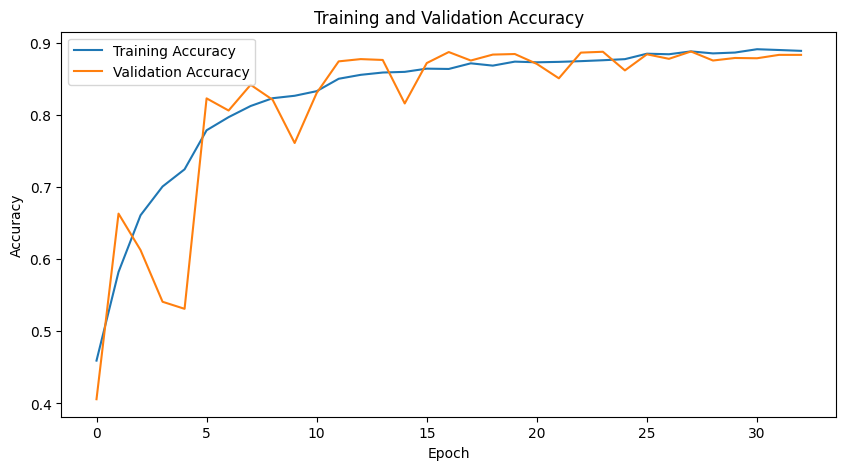

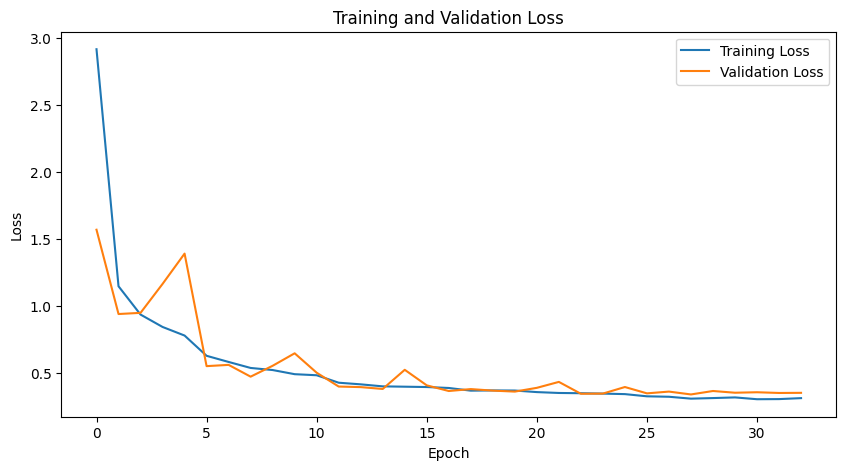

In [22]:
# Plot accuracy
plt.figure(figsize=(10,5))

plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(10,5))

plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()


In [23]:
# Reset generator
test_generator.reset()

# Prediksi model
predictions = model.predict(test_generator)

2556/2556 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step


In [24]:
# Mengambil index kelas dengan probabilitas tertinggi
predicted_classes = np.argmax(predictions, axis=1)

# Label asli
true_classes = test_generator.classes

# Nama kelas
class_labels = list(test_generator.class_indices.keys())

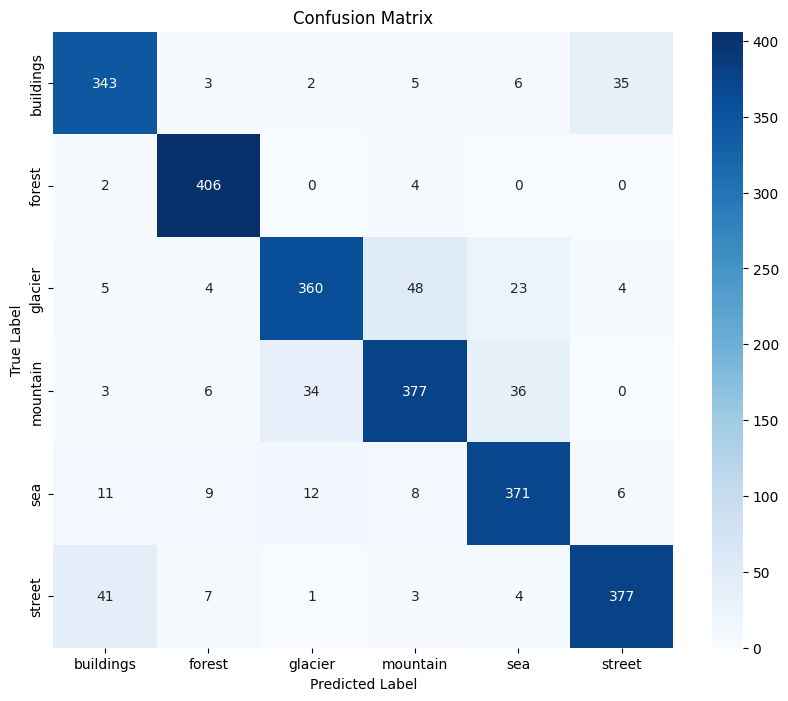

In [25]:
# Membuat confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Visualisasi confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [26]:
# Classification report
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

   buildings       0.85      0.87      0.86       394
      forest       0.93      0.99      0.96       412
     glacier       0.88      0.81      0.84       444
    mountain       0.85      0.83      0.84       456
         sea       0.84      0.89      0.87       417
      street       0.89      0.87      0.88       433

    accuracy                           0.87      2556
   macro avg       0.87      0.88      0.87      2556
weighted avg       0.87      0.87      0.87      2556



### Analisis Hasil Evaluasi

Model CNN berhasil mencapai accuracy sebesar 87% pada data testing. Nilai tersebut telah memenuhi kriteria submission Dicoding yang mensyaratkan minimal accuracy sebesar 85%.

Kelas `forest` memiliki performa terbaik karena karakteristik visualnya lebih mudah dikenali oleh model dibanding kelas lainnya.

Sementara itu, kelas `glacier` dan `mountain` memiliki performa yang sedikit lebih rendah karena kedua kelas memiliki pola visual yang cukup mirip, seperti dominasi warna alam dan tekstur pegunungan.

Secara keseluruhan, model mampu melakukan generalisasi dengan baik terhadap data baru dan menunjukkan performa klasifikasi yang stabil pada seluruh kelas dataset Intel Image Classification.

## Konversi Model

In [27]:
# Simpan model ke format SavedModel
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140665378440976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378441744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378443664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378444048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378440592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378443280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378443088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378444432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378444816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378445008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140665378443856: Te

In [28]:
# Melihat isi folder SavedModel
os.listdir("saved_model")

['saved_model.pb', 'assets', 'fingerprint.pb', 'variables']

In [29]:
# Konversi ke TFLite

# Converter TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")

# Convert model
tflite_model = converter.convert()

In [30]:
# Membuat folder tflite
os.makedirs("tflite", exist_ok=True)

# Simpan model TFLite
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model TFLite berhasil disimpan")

Model TFLite berhasil disimpan


In [31]:
# Simpan label kelas
labels = list(train_generator.class_indices.keys())

with open("tflite/label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

print("Label berhasil disimpan")

Label berhasil disimpan


In [32]:
# Install tensorflowjs
!pip install tensorflowjs

In [33]:
# Membuat folder tfjs_model
os.makedirs("tfjs_model", exist_ok=True)

In [34]:
# Konversi SavedModel ke TensorFlow.js
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    saved_model \
    tfjs_model

2026-05-02 01:06:45.238806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777684005.290489   28547 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777684005.302218   28547 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777684005.328224   28547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777684005.328265   28547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777684005.328275   28547 computation_placer.cc:177] computation placer alr

In [35]:
# Melihat isi folder TFJS
os.listdir("tfjs_model")

['group1-shard7of11.bin',
 'group1-shard2of11.bin',
 'group1-shard3of11.bin',
 'group1-shard5of11.bin',
 'group1-shard4of11.bin',
 'group1-shard6of11.bin',
 'group1-shard1of11.bin',
 'group1-shard11of11.bin',
 'group1-shard8of11.bin',
 'group1-shard9of11.bin',
 'group1-shard10of11.bin',
 'model.json']

## Inference (Optional)

In [37]:
# Mengambil satu gambar random dari test set
sample_image_path = random.choice(test_data['filepath'].values)

print("Path Gambar:")
print(sample_image_path)

Path Gambar:
combined_dataset/forest/10684.jpg


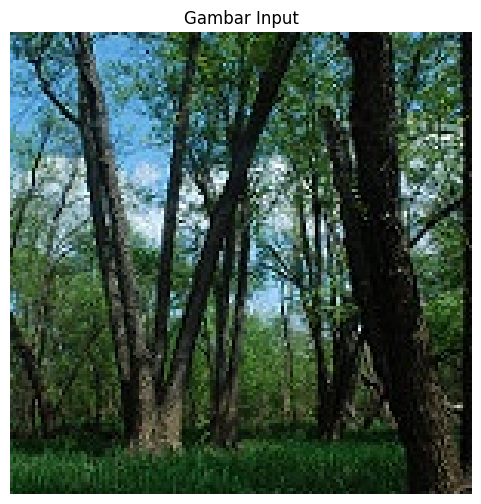

In [38]:
# Menampilkan Gambar
img = Image.open(sample_image_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title("Gambar Input")
plt.show()

In [39]:
# Preprocessing Gambar

# Resize gambar
img = img.resize((150,150))

# Konversi ke array
img_array = np.array(img)

# Normalisasi
img_array = img_array / 255.0

# Tambah dimensi batch
img_array = np.expand_dims(img_array, axis=0)

print("Shape Image:", img_array.shape)

Shape Image: (1, 150, 150, 3)


In [40]:
# Prediksi Model
prediction = model.predict(img_array)

print("Hasil Prediksi:")
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Hasil Prediksi:
[[2.2391538e-09 9.9999976e-01 2.2946750e-07 4.3162538e-13 4.9196189e-11
  2.6488445e-10]]


In [41]:
# Menentukan Label Prediksi

# Mengambil index probabilitas terbesar
predicted_index = np.argmax(prediction)

# Mengambil label kelas
class_labels = list(train_generator.class_indices.keys())
predicted_label = class_labels[predicted_index]

print("Predicted Class :", predicted_label)

Predicted Class : forest


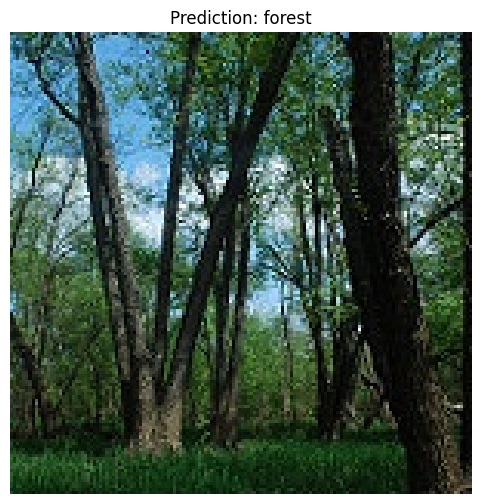

In [42]:
# Visualisasi Hasil Prediksi
img = Image.open(sample_image_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')
plt.show()

### Hasil Inference

Model berhasil melakukan prediksi terhadap gambar baru dari data testing. Hasil inference menunjukkan bahwa model CNN yang dibangun mampu mengenali kategori gambar berdasarkan pola visual yang dipelajari selama proses training.

Inference ini membuktikan bahwa model dapat digunakan untuk melakukan klasifikasi gambar secara langsung pada data baru.